# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [1]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes

#Simulator classes
import lotka_volterra as lv

#Support
import numpy as np
from matplotlib import pyplot as plt


cwd appended to system path


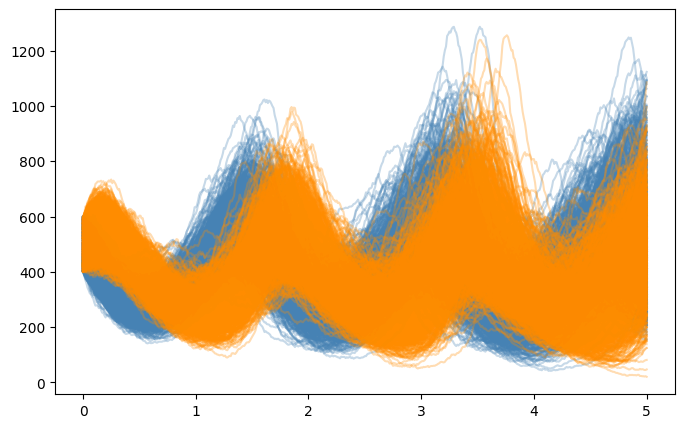

In [2]:
## Setup and tau leaping example
sample_size = 1000
alpha,beta,gamma,delta = 4,0.01,4,1
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,ts = lv.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = 10000)

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

data

In [23]:
## Setup and tau leaping example
sample_size = 1024
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [24]:
#general parameters
num_particles = 300
cores = 4

##model
def model(p,Bi):
    alpha,beta,gamma = list(p)
    _,sim = lv.tau_leaping(ic[Bi],t_max,alpha,beta,gamma,delta,dt = dt, K = K)
    obs = data[Bi]
    return sim, obs


#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])


init_params = {
    'data': data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

Running benchmarks...
Batch 1: 0.000165 sec
Batch 2: 0.000312 sec
Batch 4: 0.000646 sec
Batch 8: 0.001234 sec
Batch 16: 0.002329 sec
Batch 32: 0.004650 sec
Batch 64: 0.009246 sec
Batch 128: 0.018447 sec
Average increase in seconds per sample: 0.00014723109379701781


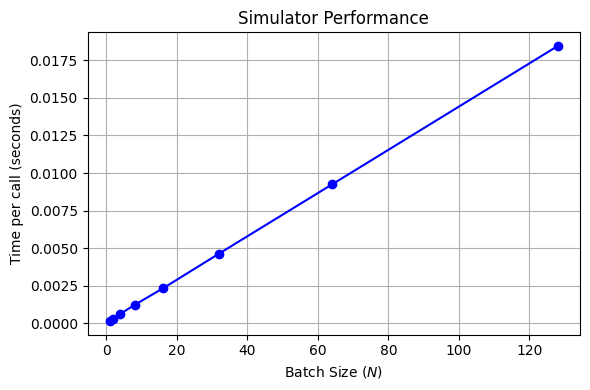

In [25]:
utils.benchmark_time([1,2,4,8,16,32,64,128],lambda n: model([alpha,beta,gamma],np.random.choice(sample_size,n)))

In [26]:
est = schemes.constant_init(init_params,[32])

tlist_c = []
# while (est.snr > 2) and (est.acceptance_rate > 0.02):
for _ in range(16):
    schemes.constant_loop(est)
    tlist_c.append(est.total_time)
    if est.acceptance_rate < 0.001:
        break

Generation: 1. Batch Size: 32. Acceptance Rate: 1.000. Step time: 1.910. Total time 1.910. post-filter threshold: 117.6687. ESS: 300.00. Log HDPR vol: 1.115
Estimated v = 2608.952. Noise: v/n = 81.530. v/N = 2.548. Estimated c = 0.076. SNR: eps^2 / (v/n) = 169.827. Time per sim: 0.003
Generation: 2. Batch Size: 32. Acceptance Rate: 0.707. Step time: 2.536. Total time 4.446. post-filter threshold: 50.1131. ESS: 290.93. Log HDPR vol: 0.417
Estimated v = 531.775. Noise: v/n = 16.618. v/N = 0.519. Estimated c = 0.080. SNR: eps^2 / (v/n) = 151.121. Time per sim: 0.003
Generation: 3. Batch Size: 32. Acceptance Rate: 0.539. Step time: 3.001. Total time 7.447. post-filter threshold: 33.7665. ESS: 285.79. Log HDPR vol: 0.036
Estimated v = 110.854. Noise: v/n = 3.464. v/N = 0.108. Estimated c = 0.054. SNR: eps^2 / (v/n) = 329.132. Time per sim: 0.003
Generation: 4. Batch Size: 32. Acceptance Rate: 0.447. Step time: 3.572. Total time 11.019. post-filter threshold: 24.9082. ESS: 290.88. Log HDPR v

In [27]:
est = schemes.fvc_init(init_params,[2,None,1.0])

tlist_a = []
# while (est.snr > 2) and (est.acceptance_rate > 0.02):
for i in range(16):
    schemes.fvc_loop(est)
    tlist_a.append(est.total_time)
    if est.acceptance_rate < 0.001:
        break

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 1.541. Total time 1.541. post-filter threshold: 111.1784. ESS: 300.00. Log HDPR vol: 1.049
Estimated v = 3673.499. Noise: v/n = 1836.749. v/N = 3.587. Estimated c = 0.385. SNR: eps^2 / (v/n) = 6.730. Time per sim: 0.003
Automatic c selection: c = 0.38510561958520273
New hyperparameter set: [np.int64(2), np.float64(0.38510561958520273), 1.0]
Batch size: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.681. Step time: 1.772. Total time 3.313. post-filter threshold: 48.9439. ESS: 286.09. Log HDPR vol: 0.555
Estimated v = 212.705. Noise: v/n = 106.353. v/N = 0.208. Estimated c = 0.210. SNR: eps^2 / (v/n) = 22.524. Time per sim: 0.002
Batch size: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.528. Step time: 1.945. Total time 5.257. post-filter threshold: 32.0591. ESS: 291.91. Log HDPR vol: -0.093
Estimated v = 63.727. Noise: v/n = 31.863. v/N = 0.062. Estimated c = 0.176. SNR: eps^2 / (v/n) = 32.256. Time per sim: 0

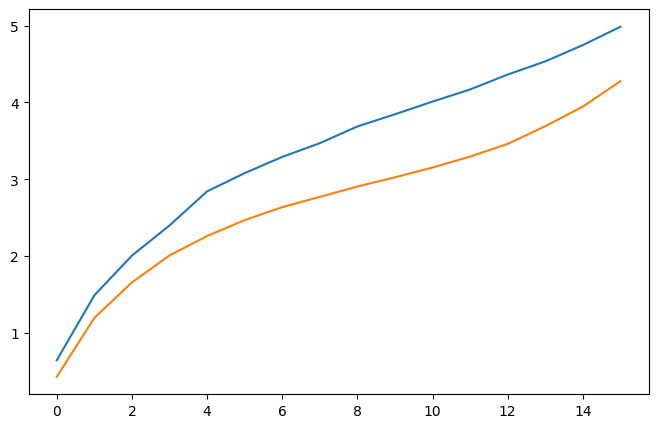

In [29]:
fig,ax = plt.subplots(figsize = (8,5))
ax.plot(np.log(tlist_c),label = 'Constant batch size')
ax.plot(np.log(tlist_a),label = 'Adaptive batch size')

### Replicates


In [2]:
## Setup and tau leaping example
sample_size = 128
alpha,beta,gamma,delta = 4,0.01,4,1
K = 10000
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,data = lv.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = K)

print(np.sum(np.any(np.any(data == 0,axis=0),axis=1)))

0


In [3]:
from numba import njit

In [4]:
#general parameters
num_particles = 300
cores = 4

#Stats function
def batch_corr(a, b):
    """Vectorized correlation between rows of a and b"""
    ma = a - np.mean(a, axis=1, keepdims=True)
    mb = b - np.mean(b, axis=1, keepdims=True)
    
    num = np.sum(ma * mb, axis=1)
    den = np.sqrt(np.sum(ma**2, axis=1) * np.sum(mb**2, axis=1))
    return num / (den + 1e-8)

def stats_func_lv(x, max_lag=5, step_size=10):
    r = x[:, :, 0]
    f = x[:, :, 1]
    
    # 1. Base Moments (Per-particle)
    stats_list = [
        np.log(np.mean(r, axis=1) + 1e-8),
        np.log(np.mean(f, axis=1) + 1e-8),
        np.log(np.var(r, axis=1) + 1),
        batch_corr(r, f) # Cross-correlation
    ]

    # 2. Add multiple Autocorrelation lags
    for i in range(1, max_lag + 1):
        lag = i * step_size # e.g., lags of 10, 20, 30, 40, 50 steps
        stats_list.append(batch_corr(r[:, :-lag], r[:, lag:]))
        stats_list.append(batch_corr(f[:, :-lag], f[:, lag:]))

    return np.column_stack(stats_list)
def stats_func(x,y,sf=stats_func_lv):
    return sf(x),sf(y)

#three replicates is fairly standard
s_obs_all_raw = stats_func_lv(data)
def model(p, Bi, num_reps=3):
    alpha, beta, gamma = p
    Bi_rep = np.repeat(Bi, num_reps)
    
    _, sim = lv.tau_leaping(
        ic[Bi_rep], t_max,
        alpha, beta, gamma, delta,
        dt=dt, K=K
    )
    s_sim = stats_func_lv(sim)
    s_obs = s_obs_all_raw[Bi_rep] 
    
    return s_sim, s_obs


def stats_func(x,y,sf=stats_func_lv):
    return x,y

prior = utils.uniform_prior([[0.0,10.0],[0.0,0.05],[0.0,10.0]])

s_data = stats_func_lv(data)

init_params = {
    'data': s_data,
    'model': model,
    'stats_func':stats_func,
    'prior':prior,
    'num_particles':num_particles,
    'cores':cores
}

Running benchmarks...
Batch 1: 0.000941 sec
Batch 2: 0.001435 sec
Batch 10: 0.005567 sec
Batch 50: 0.026015 sec
Batch 100: 0.066332 sec
Average increase in seconds per sample: 0.0005820161227311473


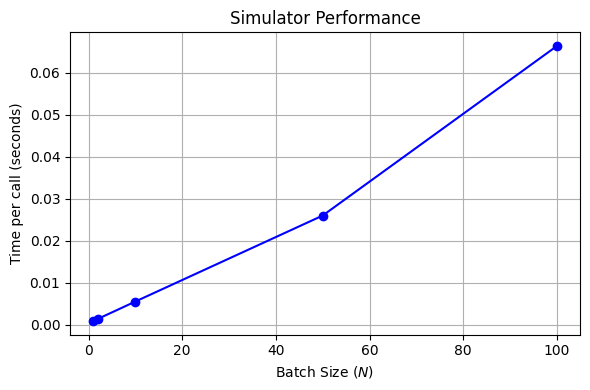

In [5]:
def func(n):
    return model([alpha,beta,gamma],np.random.choice(sample_size,n))

utils.benchmark_time([1,2,10,50,100],func)

In [6]:
est = schemes.fvc_kn_init(init_params)

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 7.261. Total time 7.261. post-filter threshold: 98.2572. ESS: 300.00. Log HDPR vol: 1.008
Estimated v = 1482.183. Noise: v/n = 741.091. v/N = 11.580. Estimated c = 0.275. SNR: eps^2 / (v/n) = 13.027. Time per sim: 0.012
Automatic c selection: c = 0.19282452900434363
New hyperparameter set: [2, np.float64(0.19282452900434363), 1.0]
Within-batch variance: 1.482e+03. Within-replicate variance: 2.558e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.640. Step time: 0.690. Total time 7.951. post-filter threshold: 45.1863. ESS: 290.35. Log HDPR vol: 0.505
Estimated v = 305.945. Noise: v/n = 152.973. v/N = 2.390. Estimated c = 0.272. SNR: eps^2 / (v/n) = 13.348. Time per sim: 0.001
Within-batch variance: 3.059e+02. Within-replicate variance: 5.115e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.511. Step time: 0.697. Total time 8.648. post-filter threshold: 31.4474.

In [7]:
est = schemes.fvc_kn2_init(init_params)

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.460. Total time 0.460. post-filter threshold: 116.6370. ESS: 300.00. Log HDPR vol: 1.040
Estimated v = 1909.659. Noise: v/n = 954.829. v/N = 14.919. Estimated c = 0.263. SNR: eps^2 / (v/n) = 14.248. Time per sim: 0.001
Automatic c selection: c = 0.1843815540492167
New hyperparameter set: [2, np.float64(0.1843815540492167), 1.0]
Within-batch variance: 1.910e+03. Within-replicate variance: 2.489e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.691. Step time: 0.601. Total time 1.061. post-filter threshold: 53.5449. ESS: 288.15. Log HDPR vol: 0.440
Estimated v = 309.684. Noise: v/n = 154.842. v/N = 2.419. Estimated c = 0.231. SNR: eps^2 / (v/n) = 18.516. Time per sim: 0.001
Within-batch variance: 3.097e+02. Within-replicate variance: 6.640e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.515. Step time: 0.653. Total time 1.714. post-filter threshold: 34.9199. 

In [8]:
est = schemes.fvc_init(init_params,p = [2,None,1])
est.reps = 3 

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.460. Total time 0.460. post-filter threshold: 114.1141. ESS: 300.00. Log HDPR vol: 1.079
Estimated v = 1088.880. Noise: v/n = 544.440. v/N = 8.507. Estimated c = 0.203. SNR: eps^2 / (v/n) = 23.918. Time per sim: 0.001
Automatic c selection: c = 0.3295740223755301
New hyperparameter set: [2, np.float64(0.3295740223755301), 1]
Variance estimate: 1459.343. C estimate: 0.000. V_total: 2873.782. batch size: 2.000. Time per sim: 0.001
Generation: 2. Batch Size: 2. Acceptance Rate: 0.696. Step time: 0.643. Total time 1.103. post-filter threshold: 49.7024. ESS: 290.77. Log HDPR vol: 0.517
Estimated v = 269.922. Noise: v/n = 134.961. v/N = 2.109. Estimated c = 0.232. SNR: eps^2 / (v/n) = 18.304. Time per sim: 0.001
Variance estimate: 278.503. C estimate: 0.157. V_total: 651.459. batch size: 2.000. Time per sim: 0.001
Generation: 3. Batch Size: 2. Acceptance Rate: 0.514. Step time: 0.730. Total time 1.833. post-filter threshold: 

KeyboardInterrupt: 

In [13]:
est = schemes.fvc_kn_init(init_params)

while est.alpha_threshold > 1.2718:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 6.868. Total time 6.868. post-filter threshold: 119.0850. ESS: 300.00. Log HDPR vol: 1.069
Estimated v = 2979.910. Noise: v/n = 1489.955. v/N = 23.281. Estimated c = 0.322. SNR: eps^2 / (v/n) = 9.518. Time per sim: 0.011
Automatic c selection: c = 0.22559027060929862
New hyperparameter set: [2, np.float64(0.22559027060929862), 1.0]
Within-batch variance: 2.980e+03. Within-replicate variance: 2.979e+03. Batch size: 2.0. Reps: 2.0
Generation: 2. Batch Size: 2. Acceptance Rate: 0.713. Step time: 0.578. Total time 7.446. post-filter threshold: 54.3350. ESS: 289.41. Log HDPR vol: 0.569
Estimated v = 873.264. Noise: v/n = 436.632. v/N = 6.822. Estimated c = 0.382. SNR: eps^2 / (v/n) = 6.762. Time per sim: 0.001
Within-batch variance: 8.733e+02. Within-replicate variance: 8.422e+02. Batch size: 2.0. Reps: 2.0
Generation: 3. Batch Size: 2. Acceptance Rate: 0.519. Step time: 0.662. Total time 8.108. post-filter threshold: 34.3756.

In [9]:
est = schemes.constant_init(init_params,p = [8])
est.reps = 3

while est.snr > 2 and est.acceptance_rate > 0.02:
    schemes.constant_loop(est)

Generation: 1. Batch Size: 8. Acceptance Rate: 1.000. Step time: 7.491. Total time 7.491. post-filter threshold: 96.9532. ESS: 300.00. Log HDPR vol: 0.896
Estimated v = 874.263. Noise: v/n = 109.283. v/N = 6.830. Estimated c = 0.104. SNR: eps^2 / (v/n) = 86.015. Time per sim: 0.012
Generation: 2. Batch Size: 8. Acceptance Rate: 0.644. Step time: 1.354. Total time 8.845. post-filter threshold: 43.1458. ESS: 290.24. Log HDPR vol: 0.246
Estimated v = 127.839. Noise: v/n = 15.980. v/N = 0.999. Estimated c = 0.090. SNR: eps^2 / (v/n) = 116.495. Time per sim: 0.001
Generation: 3. Batch Size: 8. Acceptance Rate: 0.535. Step time: 1.542. Total time 10.387. post-filter threshold: 29.3290. ESS: 288.46. Log HDPR vol: -0.230
Estimated v = 29.272. Noise: v/n = 3.659. v/N = 0.229. Estimated c = 0.063. SNR: eps^2 / (v/n) = 235.086. Time per sim: 0.001
Generation: 4. Batch Size: 8. Acceptance Rate: 0.432. Step time: 1.786. Total time 12.173. post-filter threshold: 21.6871. ESS: 283.88. Log HDPR vol: -